In [26]:
import numpy as np
import matplotlib.pyplot as plt

## A1 Optimal Control and Tipping Points 
 1) cx-(x-1)^2 * x - xy = 0 (Grass biomass does not increase or decrease)  <br />  xy = cx - (x-1)^2 * x  <br /> x = o or  y = c-(x-1)^2
2) xy-dy = 0 (Herbivore biomass  does not increase or decrease) <br /> y = 0 or x = d 


In [27]:
b = .1 # death rate grass
d = 1 # death rate herbivores 
c = .7

def f1(x,y): 
    return c*x - (x * (x-1)**2) - (x* y) 

def f2(x,y): 
    return x * y - d * y 


# Check if stable states 
x = d
y = c - (d-1)**2
print(f1(x,y))
x = 0 
y = 3 #arbitrary 
print(f1(x,y))

x = d
print(f2(x,y))
x = 4 # arbitrary
y = 0 
print(f2(x,y))


0.0
0.0
0
0


In [28]:
def nullcline_x1(c, x): 
    return c - (x - 1)**2

def nullcline_x2():
    return 0

def nullcline_y1(d): 
    return d

def nullcline_y2(): 
    return 0 

x_axis = np.linspace(0, 1.9, 1000)
x_nullcline1 = nullcline_x1(c, x_axis)
x_nullcline2 = nullcline_x2()
y_nullcline1 = nullcline_y1(d)
y_nullcline2 = nullcline_y2()


B) Compute the steady states and add them to the figure. One of these steady states is a grassrich, no-herbivore steady state: which one?
- steady state whe, fx_1 = 0 and fx_2 = 0, so finding intesersect of nullclines will show steady states. 
- Steady state 1: plug in x = d = 1 (given) into f1(x) = 0 --> y = .7 - (1-1)^2 * 1 = .7, so steady state 1 at (1,.7)
- Steady state 2: solve y = 0 = f1(x) .7-(x-1)^2 * x = 0, Solving using abc gives $$x = 1 +/-  .5 * sqrt(28/10)$$


1 0.7
0.163 -0.0005690000000000417
1.837 -0.0005690000000000417
0 0


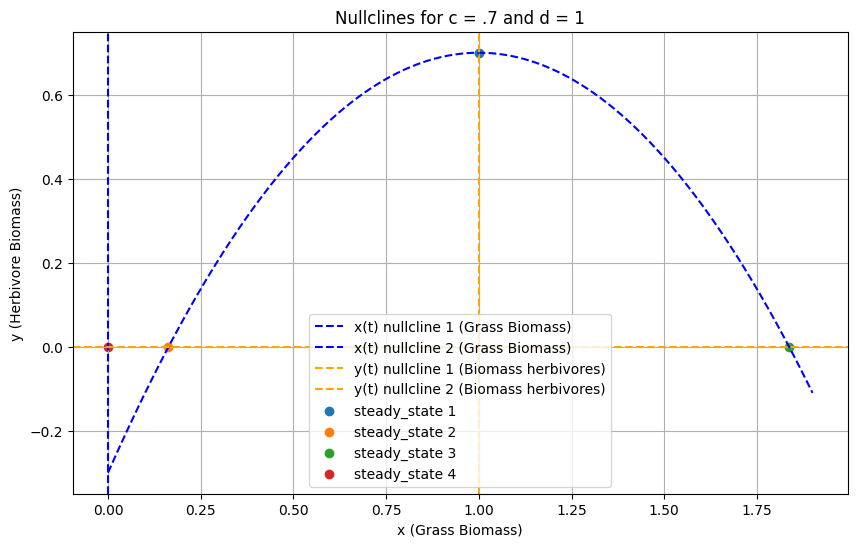

In [38]:

steady_states_x = [d , 1 + .5 * np.sqrt(28/10), 1 - .5 * np.sqrt(28/10)]
steady_states_x = [d , .163, 1.837]

steady_states_y = [nullcline_x1(c, x) for x in steady_states_x]

steady_states_x.append(0)
steady_states_y.append(nullcline_x2())

plt.figure(figsize=(10,6))
plt.plot(x_axis, x_nullcline1, linestyle = "--", color = "blue", label = "x(t) nullcline 1 (Grass Biomass)")
plt.axvline(x_nullcline2, linestyle = "--", color = "blue", label = "x(t) nullcline 2 (Grass Biomass)")

plt.axvline(y_nullcline1, linestyle = "--", color = "orange", label = "y(t) nullcline 1 (Biomass herbivores)" )
plt.axhline(y_nullcline2, linestyle = "--", color = "orange", label = "y(t) nullcline 2 (Biomass herbivores)" )

# plotting steady states: 
for i, (x, y) in enumerate(zip(steady_states_x, steady_states_y), start=1):
    plt.scatter(x, y, label=f"steady_state {i}")
    print(x,y)
plt.title("Nullclines for c = .7 and d = 1")
plt.xlabel("x (Grass Biomass)")
plt.ylabel("y (Herbivore Biomass)")
plt.legend()
plt.grid()

In [39]:
print(d , 1 + .5 * np.sqrt(28/10), 1 - .5 * np.sqrt(28/10), 0)
print(steady_states_y)

1 1.8366600265340756 0.16333997346592444 0
[0.7, -0.0005690000000000417, -0.0005690000000000417, 0]


 One of these steady states is a grassrich, no-herbivore steady state: which one?
- Grass-rich no herbivore: that is steady state 2, for (1 +  .5 * sqrt(28/10), 0), orange dot in the plot

c. Describe how the grass–herbivore ecosystem looks like in each steady state.
- Steady state 1:  sustainable state,  there is a positive steady state biomass of herbivores, 
- Steady state 2: there are no herbivores and the environment is grass rich
- There is some grass and there are some herbivores 

d) determine eigenvalues of each steady state

Jacobain (system) = 
\[
\begin{bmatrix}
-3x^2 + 4x + c - 1 - y & -x \\
x -d  & y  
\end{bmatrix}
\]
```

Steady state 1) 
steady state: 


In [40]:
import numpy as np

def jacobian(x, y, c=0.7, d=1):
    # Compute the components of the Jacobian matrix
    df1_dx = -3 * (x**2 ) + 4 *x - .3 - y
    df1_dy = -x
    df2_dx = y
    df2_dy = x - 1
    
    # Return the Jacobian matrix as a 2x2 numpy array
    return np.array([[df1_dx, df1_dy],
                     [df2_dx, df2_dy]])

# Example usage:
x_val, y_val = 1.0, 0.7  # For example, evaluate at (x=1, y=0.7)
jacobian_matrix = jacobian(x_val, y_val)
jacobian_matrix

for i in range(len(steady_states_x)): 
    x = steady_states_x[i]
    y = steady_states_y[i]
    jacobian_matrix = jacobian(x, y)
    print(f"x: {x}, y: {y} \n \n  {jacobian_matrix} \n")
    print()
    print()


x: 1, y: 0.7 
 
  [[ 0.  -1. ]
 [ 0.7  0. ]] 



x: 0.163, y: -0.0005690000000000417 
 
  [[ 2.72862e-01 -1.63000e-01]
 [-5.69000e-04 -8.37000e-01]] 



x: 1.837, y: -0.0005690000000000417 
 
  [[-3.075138e+00 -1.837000e+00]
 [-5.690000e-04  8.370000e-01]] 



x: 0, y: 0 
 
  [[-0.3  0. ]
 [ 0.  -1. ]] 



